In [1]:
%load_ext autoreload
%autoreload 2
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))
import warnings
warnings.filterwarnings("ignore")

In [5]:
# # # # # # # # # # # 
tag = '2022041821_debug03' 

which_train = '01'
which_test = 'train' # 'train'
test_ood = False
samp_size = 500

use_losses = ['SupCon','Recon']
bs = 32
n_epochs = 4

normed_latent = True
use_cuda = True
empty_cuda = True
cuda_ids = [0,1,2,3]
# n_neighs = 32
# min_dist = 0.1
save_coords = True
# # # # # # # # # # # 

ood = 'ood' if test_ood else ''
which = 'train' if which_test=='train' else 'test'
which = 'ood' if test_ood else which
    
tag_emb = '_'.join([x for x in [tag, f'{samp_size}n', which] if len(x)>0])
print(tag_emb)

2022041821_debug03_500n_train


### Load model.

In [6]:
# %%capture
import torch.nn as nn
import torch
from seqAE_model import SeqAutoencoder
from contra_seq_dataset import ContraSeqDataset
from torch.utils.data import DataLoader, RandomSampler

_anc_path = f'data/model_ready/{which_train}/train/anchor_smiles.csv'
_aug_path = f'data/model_ready/{which_train}/train/augmented_smiles.csv'
_ds = ContraSeqDataset(_anc_path, _aug_path)

model = SeqAutoencoder(max_len = 122,
                       dim_emb=512, heads=8, dim_hidden=32,
                       L_enc=6, L_dec=6, dim_ff=2048, 
                       drpt=0.1, actv='relu', eps=0.6, b_first=True)

p = f'results/models/{tag}/{n_epochs-1:02}.pt'
model.load_state_dict(torch.load(p), strict = False)
print(f"Loaded model weights {p}")

if empty_cuda:
    torch.cuda.empty_cache()

if use_cuda:
    if len(cuda_ids) == 1:
        cuda_id = cuda_ids[0]
        device = torch.device(f"cuda:{cuda_id}")
    elif len(cuda_ids) > 1:
        device =  torch.device("cuda")
        print("Let's use", len(cuda_ids), "GPUs!")
        model = nn.DataParallel(model, device_ids=cuda_ids)
        model.to(device)
else:
    device = torch.device("cpu")
    model = model.to(device)

model = model.eval()
# print(_ds.tokens)
# print(len(_ds.tokens))
# print(len('#%()+-0123456789<=>BCFHILNOPRSX[]cnos'))

Loaded model weights results/models/2022041821_debug03/03.pt
Let's use 4 GPUs!


### Dataset to evaluate.

In [21]:
from contra_seq_dataset import ContraSeqDataset, get_dataset_array, get_anc_map
import copy
import random
import numpy as np
random.seed(666)

if which_test == 'train':
    anc_path = f'data/model_ready/{which_train}/train/anchor_smiles.csv'
    aug_path = f'data/model_ready/{which_train}/train/augmented_smiles.csv'
else:
    if ood:
        tag_caboose = '_ood'
    else:
        tag_caboose = ''
    anc_path = f'data/model_ready/{which_test}/test/anchor_smiles{tag_caboose}.csv'
    aug_path = f'data/model_ready/{which_test}/test/augmented_smiles{tag_caboose}.csv'   
    
print(anc_path)

ds = ContraSeqDataset(anc_path, aug_path)
ds_arr = get_dataset_array(anc_path, aug_path)
anc_map = get_anc_map(ds_arr)
_df = copy.deepcopy(ds_arr)
# print(len(_df))

_df.columns = ['Smiles','Atype','Label'] 

if samp_size < len(anc_map):
    rand = random.sample(range(0,len(anc_map)),samp_size)
    rand_idc = np.concatenate([anc_map[x] for x in rand],axis=0)
    df = _df.iloc[rand_idc]
    idc = rand_idc
else:
    df = _df
    idc = range(len(df))
    
df.reset_index(inplace=True,drop=True)
display(df)    

data/model_ready/01/train/anchor_smiles.csv


,Smiles,Atype,Label
0,NN=c1ccc(N(CCO)CCO)n[nH]1,Anc,14946
1,Cc1cc(=NN)[nH]nc1N(CCO)CCO,Aug,14946
2,NN=c1[nH]nc(N(CCO)CCO)cc1S,Aug,14946
3,NN=c1ccc(N(CCO)C(N)CO)n[nH]1,Aug,14946
4,COCCN(CCO)c1ccc(=NN)[nH]n1,Aug,14946
...,...,...,...
2995,Cc1cc(C)nc(N2CCC(C(=O)NNC(=O)c3ccccc3)CC2)n1,Aug,12486
2996,CCc1ccnc(N2CCC(C(=O)NNC(=O)c3ccccc3)CC2)n1,Aug,12486
2997,Cc1ccnc(N2CCC(C(=O)NNC(=O)c3ccccc3N)CC2)n1,Aug,12486
2998,Cc1ccc(C(=O)NNC(=O)C2CCN(c3nccc(C)n3)CC2)cc1,Aug,12486


In [24]:
import numpy as np
from tqdm.notebook import trange, tqdm

# # # # # # 
test_bs = 1
# # # # # # 
# ! !!!!!!!!! !!!!!!   ! ! ! !  !!!!!!!!!
loader = DataLoader(ds, batch_size=test_bs, sampler=idc, 
                    num_workers=0, pin_memory=True)
latents = []
for samp in tqdm(loader, total=len(df)//test_bs):
#     print(samp['smiles'] ,samp['label'], samp['atype'])
    for k,v in samp.items():
        if torch.is_tensor(v):
            samp[k] = v.to(device)
    latent, _ = model.forward(samp['seq'], samp['pad_mask'], 
                              samp['avg_mask'], samp['out_mask'], normed_latent)
    latent = latent.cpu().detach().numpy()
    latents.append(latent)
    
latents = np.stack(latents,axis=0)
if test_bs==1:
    latents = latents.squeeze(1)
else:
    latents = np.reshape(latents, (-1,32))
print(latents.shape)

  0%|          | 0/3000 [00:00<?, ?it/s]

(3000, 32)


,Smiles,Atype,Label,Mol
0,NN=c1ccc(N(CCO)CCO)n[nH]1,Anc,14946,"<img data-content=""rdkit/molecule"" src="""" alt=""Mol""/>"
1,Cc1cc(=NN)[nH]nc1N(CCO)CCO,Aug,14946,"<img data-content=""rdkit/molecule"" src="""" alt=""Mol""/>"
2,NN=c1[nH]nc(N(CCO)CCO)cc1S,Aug,14946,"<img data-content=""rdkit/molecule"" src="""" alt=""Mol""/>"
3,NN=c1ccc(N(CCO)C(N)CO)n[nH]1,Aug,14946,"<img data-content=""rdkit/molecule"" src="""" alt=""Mol""/>"
4,COCCN(CCO)c1ccc(=NN)[nH]n1,Aug,14946,"<img data-content=""rdkit/molecule"" src="""" alt=""Mol""/>"
5,COCCN(CCO)c1ccc(=NN)[nH]n1,Aug,14946,"<img data-content=""rdkit/molecule"" src="""" alt=""Mol""/>"
6,O=C(c1c(F)cccc1F)N1CCc2c(cnn2-c2ccc(F)cc2Cl)C1,Anc,12354,"<img data-content=""rdkit/molecule"" src="""" alt=""Mol""/>"
7,O=C(c1c(F)cccc1F)N1CCc2c(cnn2-c2c(O)cc(F)cc2Cl)C1,Aug,12354,"<img data-content=""rdkit/molecule"" src="""" alt=""Mol""/>"
8,O=C(c1c(F)cccc1F)N1CCc2c(cnn2-c2ccc(F)cc2Cl)C1O,Aug,12354,"<img data-content=""rdkit/molecule"" src="""" alt=""Mol""/>"
9,Cc1ccc(F)c(C(=O)N2CCc3c(cnn3-c3ccc(F)cc3Cl)C2)c1F,Aug,12354,"<img data-content=""rdkit/molecule"" src="""" alt=""Mol""/>"

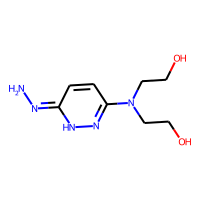
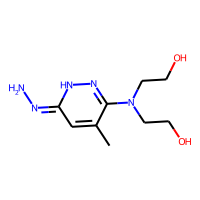
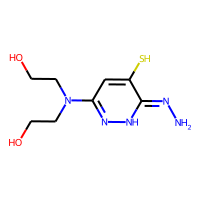
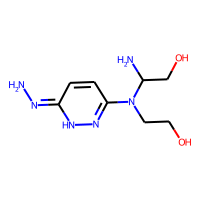
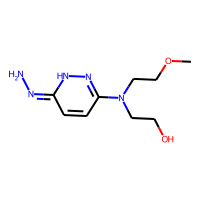
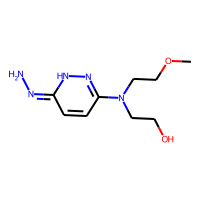
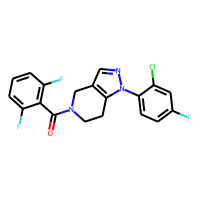
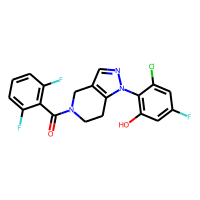
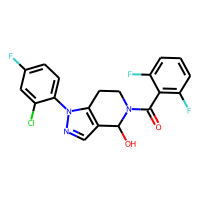
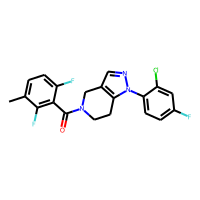
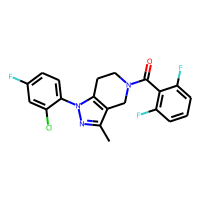
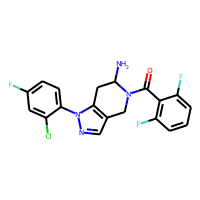
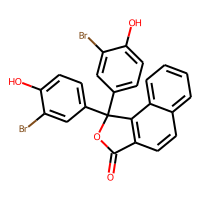
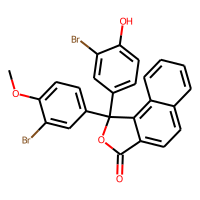
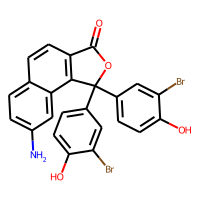
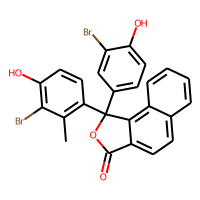
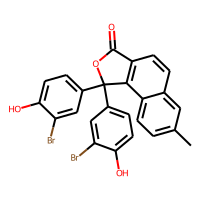
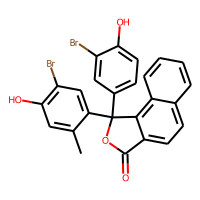
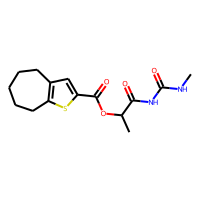
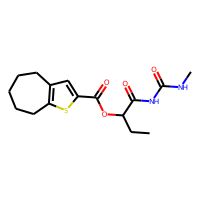
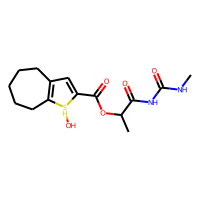
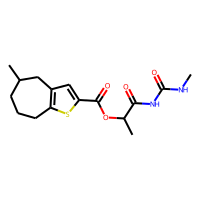
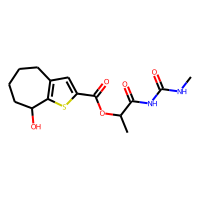
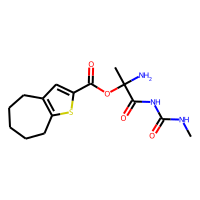
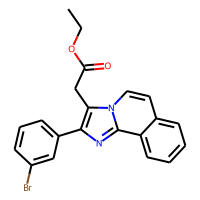
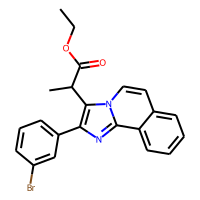
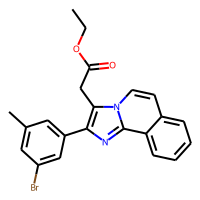
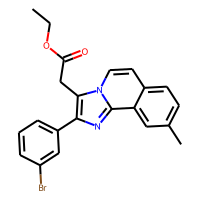
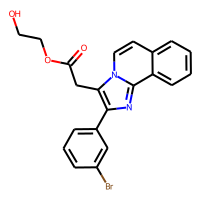
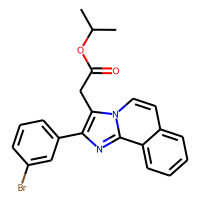

In [25]:
import pandas as pd
from rdkit.Chem import PandasTools

PandasTools.AddMoleculeColumnToFrame(df,'Smiles','Mol',includeFingerprints=False)
df[:30]

In [26]:
len(df)
latents.shape

(3000, 32)

### Fit UMAP function.

In [27]:
# # # # # # # # # # # 
n_neighs = 16
min_dist = 0.05
# # # # # # # # # # # 

In [30]:
import umap.umap_ as umap
umapper = umap.UMAP(n_neighbors=n_neighs, min_dist=min_dist, 
                    n_components=2, metric='euclidean')
embedding = umapper.fit_transform(latents)

df['x'] = embedding[:, 0]
df['y'] = embedding[:, 1]

pt = str(min_dist).split('.')[1]
tag_coords = '_'.join([tag_emb, f'{n_neighs}neigh', f'mindist0pt{pt}'])
    
if save_coords:
    csv_out = f'results/umapped_dfs/{tag_coords}.csv'
    df.to_csv(csv_out,index=False)
    print(f"Saved smiles and coords to {csv_out}!")

Saved smiles and coords to results/umapped_dfs/2022041821_debug03_500n_train_16neigh_mindist0pt05.csv!


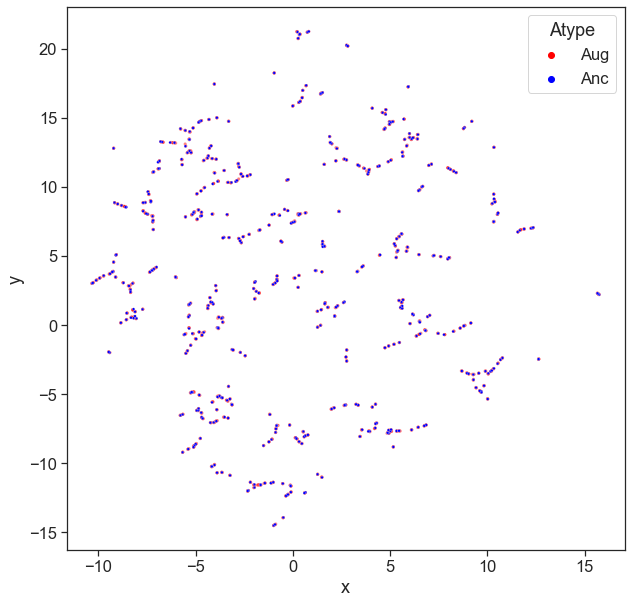

In [31]:
import seaborn as sns 
import matplotlib.pylab as plt

sns.set_theme(style='ticks',font_scale=1.5)

plt.figure(figsize=(10,10))

sns.scatterplot(data=df[df['Atype']=='Aug'], x='x', y='y', hue='Atype', 
                alpha=0.5, s=10, palette={'Aug':'red'})
sns.scatterplot(data=df[df['Atype']=='Anc'], x='x', y='y', hue='Atype', 
                alpha=1., s=7, palette={'Anc':'blue'})
png_out = f'results/umap_figs/{tag_coords}.png'
plt.savefig(png_out, bbox_inches='tight')
plt.show()

In [14]:
import pandas as pd
from rdkit.Chem import PandasTools

PandasTools.AddMoleculeColumnToFrame(df,'Smiles','Mol',includeFingerprints=False)
df = df[["Smiles","Mol","Label","Atype","x","y"]]

In [32]:
%matplotlib inline
import plotly.graph_objs as go

from ipywidgets import Image, Layout, HBox, VBox
from rdkit.Chem import Draw
import PIL

import ipywidgets as widgets
import io

# Assemble all the traces.
trace_anchors = (go.Scattergl(x=df[df.Atype=='Anc']['x'], 
                           y=df[df.Atype=='Anc']['y'], 
                           name='Anchors',
                           marker=dict(size=3, opacity=0.75, color='blue'),
                           hoverinfo='text',
                           text=df[df.Atype=='Anc']['Smiles'],
                           mode='markers'))
trace_augmentations = (go.Scattergl(x=df[df.Atype=='Aug']['x'], 
                           y=df[df.Atype=='Aug']['y'], 
                           name='Augmentations',
                           marker=dict(size=3, opacity=0.75, color='red'), #chartreuse
                           hoverinfo='text',
                           text=df[df.Atype=='Aug']['Smiles'],
                           mode='markers'))
data = [trace_augmentations, trace_anchors, ]

# Make figure.
fig = go.FigureWidget(data=data)
# fig.layout.hovermode = 'closest'
fig.update_layout(template='simple_white', autosize=False, height=512)
fig.update_yaxes(scaleanchor = "x", scaleratio = 1.)

# Show-mol-on-hover function.
# img = open('white.png','rb').read()
img = PIL.Image.new('1', (256, 256)).tobytes()
image_widget = Image(value=img)

def hover_fn(trace, points, state):
    
    if points.point_inds:
        if trace['name']=='Anchors':
            my_df = df[df.Atype=='Anc']
        elif trace['name']=='Augmentations':
            my_df = df[df.Atype=='Aug']
            
        idx = points.point_inds[0]
        datum = my_df.iloc[idx]
        mol = datum.Mol

        img = Draw.MolToImage(mol,size=(256, 512))  ### to make mol image smaller, alter first dim. 
        imgByteArr = io.BytesIO()
        img.save(imgByteArr, format='PNG')
        imgByteArr = imgByteArr.getvalue()
        image_widget.value = imgByteArr

for trace_num in range(len(fig.data)):
    fig.data[trace_num].on_hover(hover_fn)  
HBox([HBox([image_widget]),fig])